# 01 · Linear Regression

**Contents**

1. Problem statement
2. The loss function $J(\boldsymbol{\theta})$
3. Two matrix-calculus facts (proved)
4. The gradient of $J$
5. Batch gradient descent
6. The learning rate $\alpha$ (and why feature scaling matters)
7. The normal equation
8. Convexity: why there is a single global minimum
9. Least squares = maximum likelihood under Gaussian noise
10. Metrics for regression

Regularisation, input variables and the assumptions of the model are in notebook **03**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(42)

## 1. Problem statement

Given $m$ examples $\{(\mathbf{x}^{(i)}, y^{(i)})\}_{i=1}^m$ with $\mathbf{x}^{(i)} \in \mathbb{R}^n$ and $y^{(i)} \in \mathbb{R}$, find parameters $\boldsymbol{\theta} \in \mathbb{R}^{n+1}$ of the **linear model**

$$
h_{\boldsymbol{\theta}}(\mathbf{x}) = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n = \boldsymbol{\theta}^\top \mathbf{x}\qquad (x_0 = 1)
$$

that predicts $y$ as well as possible. With the design matrix $\mathbf{X}$ (one row per example, first column ones), all predictions at once are $\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\theta}$.

- $\theta_0$ is the prediction when all features are 0 (intercept).
- $\theta_j$ is the change in the prediction when $x_j$ increases by one unit **with all other features fixed**.

"Linear" means linear **in the parameters**. The features can be any fixed transformation of the raw inputs ($x^2$, $\log x$, $x_1 x_2$, …) and the model is still linear regression (see notebook 03).

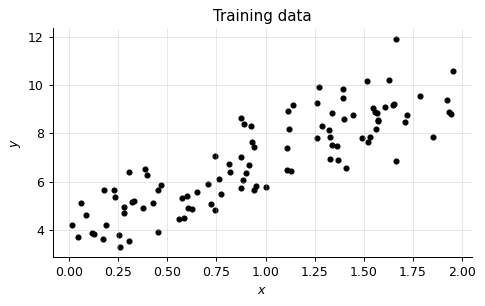

In [2]:
# Running example: y = 4 + 3 x + noise
m = 100
x = rng.uniform(0, 2, m)
y = 4 + 3 * x + rng.normal(0, 1, m)
X = np.c_[np.ones(m), x]          # design matrix  (m x 2)

plt.figure(figsize=(5.5, 3.5))
plt.scatter(x, y, s=15, color="k")
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.title("Training data")
plt.tight_layout(); plt.show()

## 2. The loss function

For each example the **residual** is $r^{(i)} = h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)}) - y^{(i)}$. We use the **mean squared error** (the $\tfrac12$ only makes derivatives cleaner, it does not move the minimum):

$$
J(\boldsymbol{\theta}) = \frac{1}{2m}\sum_{i=1}^m \big(\boldsymbol{\theta}^\top\mathbf{x}^{(i)} - y^{(i)}\big)^2 = \frac{1}{2m}\,\lVert \mathbf{X}\boldsymbol{\theta} - \mathbf{y}\rVert^2 = \frac{1}{2m}(\mathbf{X}\boldsymbol{\theta} - \mathbf{y})^\top(\mathbf{X}\boldsymbol{\theta} - \mathbf{y}).
$$

Why squares?
- They penalise positive and negative errors equally and large errors a lot.
- $J$ is smooth and convex (section 8) so it is easy to minimise.
- It is exactly what maximum likelihood gives if the noise is Gaussian (section 9).

Downside: because errors are squared, a few **outliers** can dominate the fit. (Alternatives: absolute error, Huber loss.)

## 3. Two matrix-calculus facts

The gradient $\nabla_{\boldsymbol{\theta}} J$ is the vector of partial derivatives $\big(\partial J/\partial\theta_0, \dots, \partial J/\partial\theta_n\big)^\top$. We only need two rules.

**Fact 1.** For a constant vector $\mathbf{a}$: $\;\nabla_{\boldsymbol{\theta}}\,(\mathbf{a}^\top\boldsymbol{\theta}) = \mathbf{a}$.

*Proof.* $\mathbf{a}^\top\boldsymbol{\theta} = \sum_k a_k\theta_k$, so $\partial/\partial\theta_j = a_j$. $\blacksquare$

**Fact 2.** For a constant symmetric matrix $\mathbf{A}$: $\;\nabla_{\boldsymbol{\theta}}\,(\boldsymbol{\theta}^\top\mathbf{A}\boldsymbol{\theta}) = 2\mathbf{A}\boldsymbol{\theta}$.

*Proof.* $\boldsymbol{\theta}^\top\mathbf{A}\boldsymbol{\theta} = \sum_k\sum_l \theta_k A_{kl}\theta_l$. Differentiating w.r.t. $\theta_j$ picks the terms with $k=j$ and those with $l=j$:
$\sum_l A_{jl}\theta_l + \sum_k \theta_k A_{kj} = 2\sum_l A_{jl}\theta_l = 2(\mathbf{A}\boldsymbol{\theta})_j$ using $A_{kj} = A_{jk}$. $\blacksquare$

## 4. The gradient of $J$

Expand the quadratic form:

$$
2m\,J(\boldsymbol{\theta}) = \boldsymbol{\theta}^\top\mathbf{X}^\top\mathbf{X}\boldsymbol{\theta} - 2\,(\mathbf{X}^\top\mathbf{y})^\top\boldsymbol{\theta} + \mathbf{y}^\top\mathbf{y}.
$$

$\mathbf{X}^\top\mathbf{X}$ is symmetric, so by Facts 1 and 2:

$$
\boxed{\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta}) = \frac{1}{m}\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta} - \mathbf{y})}
\qquad\text{i.e.}\qquad
\frac{\partial J}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^m \big(h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)}) - y^{(i)}\big)\,x^{(i)}_j .
$$

The component form is also easy to get directly with the chain rule: $\frac{\partial}{\partial\theta_j}\frac{1}{2}(\boldsymbol{\theta}^\top\mathbf{x} - y)^2 = (\boldsymbol{\theta}^\top\mathbf{x} - y)\,x_j$.

**Reading it:** each example pushes $\boldsymbol{\theta}$ proportionally to its error times its input. Examples that are already well predicted barely contribute.

In [3]:
def J(theta, X, y):
    r = X @ theta - y
    return (r @ r) / (2 * len(y))

def grad_J(theta, X, y):
    return X.T @ (X @ theta - y) / len(y)

# check the analytic gradient against finite differences
theta_test = np.array([1.0, -2.0]); eps = 1e-6
num = np.array([(J(theta_test + eps * e, X, y) - J(theta_test - eps * e, X, y)) / (2 * eps) for e in np.eye(2)])
print("analytic :", grad_J(theta_test, X, y))
print("numerical:", num)

analytic : [-7.85318134 -9.13831664]
numerical: [-7.85318134 -9.13831664]


## 5. Batch gradient descent

The gradient points in the direction of steepest **increase** of $J$. So take small steps in the opposite direction:

$$
\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \alpha\,\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta}) = \boldsymbol{\theta} - \frac{\alpha}{m}\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta} - \mathbf{y}).
$$

*Why does a small step decrease $J$?* First-order Taylor expansion: $J(\boldsymbol{\theta} - \alpha\mathbf{g}) \approx J(\boldsymbol{\theta}) - \alpha\,\mathbf{g}^\top\mathbf{g} = J(\boldsymbol{\theta}) - \alpha\lVert\mathbf{g}\rVert^2 < J(\boldsymbol{\theta})$ whenever $\mathbf{g}\neq 0$ and $\alpha$ is small.

**Algorithm (batch GD)**
1. Initialise $\boldsymbol{\theta}$ (e.g. zeros; for a convex $J$ the start does not change the answer).
2. Repeat until $J$ stops decreasing (or for a fixed number of iterations): compute the gradient **using all $m$ examples**, update all $\theta_j$ **simultaneously**.

*Batch* means every step uses the full training set. Variants: **stochastic GD** uses one random example per step, **mini-batch GD** uses a small random subset (e.g. 32–512). They are noisier per step but much cheaper, and they are what is used for large $m$ and in deep learning.

theta from gradient descent: [3.949 3.038]


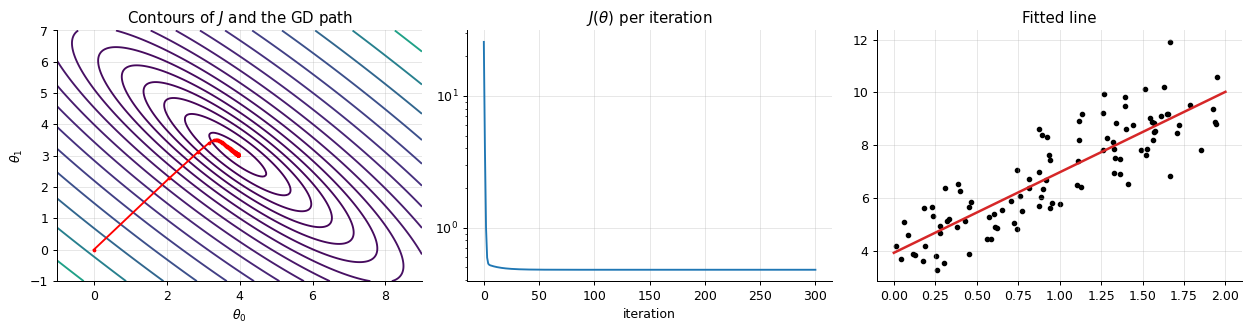

In [4]:
def gradient_descent(X, y, alpha, n_iters, theta0=None):
    theta = np.zeros(X.shape[1]) if theta0 is None else theta0.astype(float).copy()
    path, costs = [theta.copy()], [J(theta, X, y)]
    for _ in range(n_iters):
        theta = theta - alpha * grad_J(theta, X, y)
        path.append(theta.copy()); costs.append(J(theta, X, y))
    return theta, np.array(path), np.array(costs)

theta_gd, path, costs = gradient_descent(X, y, alpha=0.3, n_iters=300)
print("theta from gradient descent:", theta_gd.round(3))

T0, T1 = np.meshgrid(np.linspace(-1, 9, 200), np.linspace(-1, 7, 200))
Jgrid = np.array([[J(np.array([a, b]), X, y) for a, b in zip(r0, r1)] for r0, r1 in zip(T0, T1)])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].contour(T0, T1, Jgrid, levels=np.logspace(-0.5, 1.8, 20), cmap="viridis")
axes[0].plot(path[:, 0], path[:, 1], "r.-", ms=4)
axes[0].set_xlabel(r"$\theta_0$"); axes[0].set_ylabel(r"$\theta_1$"); axes[0].set_title("Contours of $J$ and the GD path")
axes[1].plot(costs); axes[1].set_yscale("log"); axes[1].set_xlabel("iteration"); axes[1].set_title(r"$J(\theta)$ per iteration")
axes[2].scatter(x, y, s=12, color="k"); xs = np.linspace(0, 2, 10)
axes[2].plot(xs, theta_gd[0] + theta_gd[1] * xs, "C3", lw=2); axes[2].set_title("Fitted line")
plt.tight_layout(); plt.show()

## 6. The learning rate $\alpha$

- **Too small**: converges, but needs many iterations.
- **Too large**: overshoots the minimum; $J$ oscillates or grows (divergence).

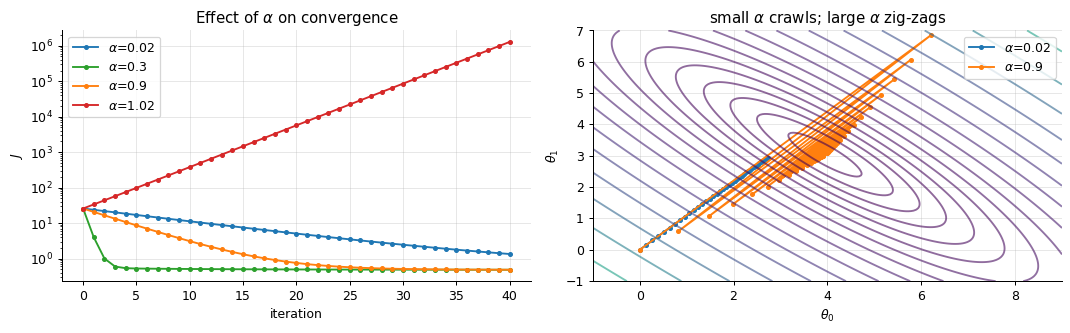

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for a, c in zip([0.02, 0.3, 0.9, 1.02], ["C0", "C2", "C1", "C3"]):
    _, p, cst = gradient_descent(X, y, alpha=a, n_iters=40)
    axes[0].plot(cst, color=c, marker=".", label=rf"$\alpha$={a}")
    if a in (0.02, 0.9):
        axes[1].plot(p[:, 0], p[:, 1], ".-", color=c, label=rf"$\alpha$={a}")
axes[0].set_yscale("log"); axes[0].set_xlabel("iteration"); axes[0].set_ylabel("$J$"); axes[0].legend()
axes[0].set_title(r"Effect of $\alpha$ on convergence")
axes[1].contour(T0, T1, Jgrid, levels=np.logspace(-0.5, 1.8, 20), cmap="viridis", alpha=0.6)
axes[1].legend(); axes[1].set_title("small $\\alpha$ crawls; large $\\alpha$ zig-zags")
axes[1].set_xlabel(r"$\theta_0$"); axes[1].set_ylabel(r"$\theta_1$")
plt.tight_layout(); plt.show()

### How large can $\alpha$ be? (proof)

Let $\mathbf{H} = \frac{1}{m}\mathbf{X}^\top\mathbf{X}$ and let $\boldsymbol{\theta}^*$ be the minimiser, which satisfies $\mathbf{X}^\top\mathbf{X}\boldsymbol{\theta}^* = \mathbf{X}^\top\mathbf{y}$ (section 7). Then the gradient can be written as

$$
\nabla J(\boldsymbol{\theta}) = \tfrac{1}{m}(\mathbf{X}^\top\mathbf{X}\boldsymbol{\theta} - \mathbf{X}^\top\mathbf{y}) = \mathbf{H}(\boldsymbol{\theta} - \boldsymbol{\theta}^*).
$$

Define the error $\mathbf{e}_t = \boldsymbol{\theta}_t - \boldsymbol{\theta}^*$. The update becomes

$$
\mathbf{e}_{t+1} = \mathbf{e}_t - \alpha\mathbf{H}\mathbf{e}_t = (\mathbf{I} - \alpha\mathbf{H})\,\mathbf{e}_t \quad\Rightarrow\quad \mathbf{e}_t = (\mathbf{I} - \alpha\mathbf{H})^t\,\mathbf{e}_0 .
$$

$\mathbf{H}$ is symmetric, so it has orthonormal eigenvectors $\mathbf{v}_k$ with eigenvalues $\lambda_k \ge 0$. Along $\mathbf{v}_k$ the error is multiplied by $(1-\alpha\lambda_k)$ at every step. It shrinks to 0 iff $|1-\alpha\lambda_k| < 1$ for all $k$ with $\lambda_k>0$, i.e.

$$
\boxed{0 < \alpha < \frac{2}{\lambda_{\max}(\mathbf{H})}}.
$$

Two consequences:
- The **slowest** direction is the one with the smallest eigenvalue: it shrinks by $(1-\alpha\lambda_{\min})$ per step. With the largest safe $\alpha \approx 1/\lambda_{\max}$ that is $(1 - \lambda_{\min}/\lambda_{\max})$. When the ratio $\kappa = \lambda_{\max}/\lambda_{\min}$ (**condition number**) is large, GD is slow: the contours are long thin ellipses and GD zig-zags across them.
- **Feature scaling** fixes this. If features are on very different scales (e.g. age in years and income in euros), $\kappa$ is huge. **Standardising** each feature, $\tilde{x}_j = (x_j - \mu_j)/\sigma_j$, makes the contours much rounder.

In [6]:
H = X.T @ X / m
lam = np.linalg.eigvalsh(H)
print(f"eigenvalues of H: {lam.round(3)} -> alpha must be < {2/lam.max():.3f}  (1.02 diverged, 0.9 did not)")

# Feature scaling: same problem with x measured in "thousandths" (x * 1000)
Xbig = np.c_[np.ones(m), 1000 * x]
Xstd = np.c_[np.ones(m), (x - x.mean()) / x.std()]
for name, M in [("raw x", X), ("x*1000", Xbig), ("standardised x", Xstd)]:
    l = np.linalg.eigvalsh(M.T @ M / m)
    print(f"{name:>15}: condition number = {l.max()/l.min():12.1f}")

eigenvalues of H: [0.141 2.103] -> alpha must be < 0.951  (1.02 diverged, 0.9 did not)
          raw x: condition number =         14.9
         x*1000: condition number =    5220238.7
 standardised x: condition number =          1.0


## 7. The normal equation

Since $J$ is a smooth convex function (section 8), $\boldsymbol{\theta}^*$ is a minimiser **iff** the gradient is zero:

$$
\frac{1}{m}\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta} - \mathbf{y}) = \mathbf{0}
\;\Longleftrightarrow\;
\mathbf{X}^\top\mathbf{X}\,\boldsymbol{\theta} = \mathbf{X}^\top\mathbf{y}
\quad(\text{the "normal equations"}).
$$

If $\mathbf{X}^\top\mathbf{X}$ is invertible:

$$
\boxed{\boldsymbol{\theta}^* = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}}
$$

**Geometric meaning ("normal" = perpendicular).** The equations say $\mathbf{X}^\top(\mathbf{y} - \mathbf{X}\boldsymbol{\theta}^*) = \mathbf{0}$: the residual vector is perpendicular to every column of $\mathbf{X}$. So $\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\theta}^*$ is the **orthogonal projection** of $\mathbf{y}$ onto the space spanned by the columns of $\mathbf{X}$, the closest point in that space to $\mathbf{y}$. A consequence (first column of ones): $\sum_i r^{(i)} = 0$, the residuals of a model with intercept average to zero.

**When is $\mathbf{X}^\top\mathbf{X}$ invertible?** Exactly when the columns of $\mathbf{X}$ are linearly independent (proof in section 8). It fails if $m < n+1$ or if a feature is a linear combination of others (e.g. duplicated feature, or all one-hot columns plus the intercept). Then there are infinitely many minimisers; use the pseudo-inverse (`np.linalg.lstsq`, which returns the minimum-norm one) or add L2 regularisation (notebook 03).

**Normal equation vs. gradient descent**

| | Normal equation | Gradient descent |
|---|---|---|
| Hyperparameters | none | $\alpha$, number of iterations |
| Cost | $O(mn^2 + n^3)$ once | $O(mn)$ per iteration |
| Good when | $n$ up to a few thousand | $n$ or $m$ very large, streaming data |
| Generalises to other losses | no (only squared loss has a closed form) | yes (logistic, softmax, neural nets…) |

In practice, never form the inverse explicitly; solve the linear system (`np.linalg.solve`) or use `np.linalg.lstsq` (QR/SVD), which is numerically more stable.

In [7]:
theta_ne = np.linalg.solve(X.T @ X, X.T @ y)
theta_ls = np.linalg.lstsq(X, y, rcond=None)[0]
print("normal equation :", theta_ne.round(4))
print("lstsq           :", theta_ls.round(4))
print("gradient descent:", theta_gd.round(4))
res = y - X @ theta_ne
print("X^T (y - X theta*) =", (X.T @ res).round(10), " <- residual orthogonal to the columns of X")

normal equation : [3.9487 3.0383]
lstsq           : [3.9487 3.0383]
gradient descent: [3.9487 3.0383]
X^T (y - X theta*) = [0. 0.]  <- residual orthogonal to the columns of X


## 8. Convexity

**Definition.** $J$ is convex if for any two points and any $t\in[0,1]$:
$J\big(t\boldsymbol{\theta}_a + (1-t)\boldsymbol{\theta}_b\big) \le t\,J(\boldsymbol{\theta}_a) + (1-t)\,J(\boldsymbol{\theta}_b)$: the chord lies above the graph ("bowl shape").

**Why we care.** For a convex differentiable function, **every point with zero gradient is a global minimum**. There are no bad local minima, so gradient descent (with a valid $\alpha$) finds the global optimum from any starting point.

**Second-order test.** A twice-differentiable $J$ is convex iff its Hessian $\nabla^2 J$ (matrix of second derivatives) is **positive semi-definite** (PSD) everywhere: $\mathbf{v}^\top\nabla^2 J\,\mathbf{v} \ge 0$ for every $\mathbf{v}$. If it is positive definite ($>0$ for $\mathbf{v}\ne 0$), $J$ is **strictly** convex and the minimum is unique.

**Proof that MSE is convex.** Differentiate the gradient $\frac{1}{m}(\mathbf{X}^\top\mathbf{X}\boldsymbol{\theta} - \mathbf{X}^\top\mathbf{y})$ once more:

$$
\nabla^2 J = \frac{1}{m}\mathbf{X}^\top\mathbf{X} \quad(\text{constant: } J \text{ is a quadratic bowl}).
$$

For any $\mathbf{v}$: $\;\mathbf{v}^\top\mathbf{X}^\top\mathbf{X}\mathbf{v} = (\mathbf{X}\mathbf{v})^\top(\mathbf{X}\mathbf{v}) = \lVert\mathbf{X}\mathbf{v}\rVert^2 \ge 0$. So $J$ is convex. $\blacksquare$

It is **strictly** convex iff $\lVert\mathbf{X}\mathbf{v}\rVert^2 > 0$ for every $\mathbf{v}\neq 0$, i.e. iff $\mathbf{X}\mathbf{v}\neq\mathbf{0}$ for $\mathbf{v}\neq 0$, which is the definition of **linearly independent columns**. The same condition makes $\mathbf{X}^\top\mathbf{X}$ invertible (a PD matrix has no zero eigenvalue), which justifies the normal-equation formula.

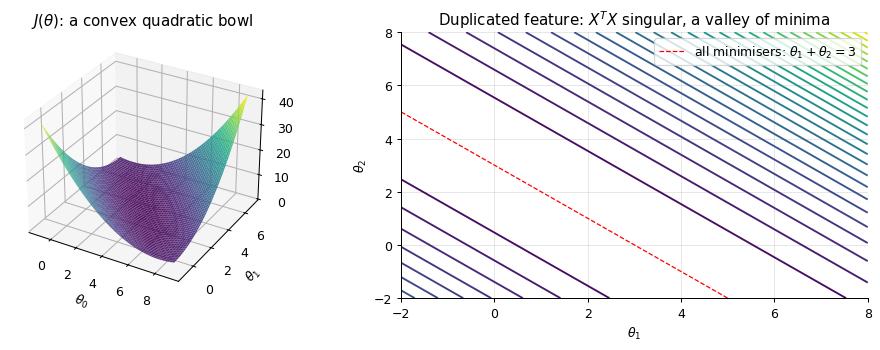

In [8]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(11, 4))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(T0, T1, Jgrid, cmap="viridis", alpha=0.9, linewidth=0)
ax.set_xlabel(r"$\theta_0$"); ax.set_ylabel(r"$\theta_1$"); ax.set_title(r"$J(\theta)$: a convex quadratic bowl")
# Degenerate case: duplicated feature -> flat valley (convex but not strictly)
Xdup = np.c_[x, x]
A, B = np.meshgrid(np.linspace(-2, 8, 200), np.linspace(-2, 8, 200))
Jdup = np.array([[J(np.array([a, b]), Xdup, 3 * x) for a, b in zip(ra, rb)] for ra, rb in zip(A, B)])
ax2 = fig.add_subplot(1, 2, 2)
ax2.contour(A, B, Jdup, levels=30, cmap="viridis")
ax2.plot([-2, 5], [5, -2], "r--", lw=1, label=r"all minimisers: $\theta_1+\theta_2=3$")
ax2.set_xlabel(r"$\theta_1$"); ax2.set_ylabel(r"$\theta_2$"); ax2.legend(loc="upper right")
ax2.set_title("Duplicated feature: $X^TX$ singular, a valley of minima")
plt.tight_layout(); plt.show()

## 9. Least squares = maximum likelihood

**Probabilistic model.** Assume the data were generated as

$$
y^{(i)} = \boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \varepsilon^{(i)}, \qquad \varepsilon^{(i)} \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0,\sigma^2),
$$

i.e. $y^{(i)} \mid \mathbf{x}^{(i)} \sim \mathcal{N}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)}, \sigma^2)$ with density

$$
p(y^{(i)}\mid\mathbf{x}^{(i)};\boldsymbol{\theta}) = \frac{1}{\sqrt{2\pi}\,\sigma}\exp\!\left(-\frac{(y^{(i)} - \boldsymbol{\theta}^\top\mathbf{x}^{(i)})^2}{2\sigma^2}\right).
$$

**Maximum likelihood (MLE)**: choose the $\boldsymbol{\theta}$ that makes the observed data most probable. With independent examples the likelihood is a product, and it is easier to maximise its log (log is increasing, so the maximiser is the same):

$$
\log L(\boldsymbol{\theta}) = \sum_{i=1}^m \log p(y^{(i)}\mid\mathbf{x}^{(i)};\boldsymbol{\theta})
= \underbrace{-m\log(\sqrt{2\pi}\sigma)}_{\text{does not depend on }\boldsymbol{\theta}} \;-\; \frac{1}{2\sigma^2}\sum_{i=1}^m\big(y^{(i)} - \boldsymbol{\theta}^\top\mathbf{x}^{(i)}\big)^2 .
$$

Maximising this over $\boldsymbol{\theta}$ is the same as minimising the sum of squares, since the constant and the positive factor $1/(2\sigma^2)$ don't change the arg-min:

$$
\boxed{\arg\max_{\boldsymbol{\theta}} \log L(\boldsymbol{\theta}) = \arg\min_{\boldsymbol{\theta}} \sum_{i}\big(y^{(i)} - \boldsymbol{\theta}^\top\mathbf{x}^{(i)}\big)^2 = \arg\min_{\boldsymbol{\theta}} J(\boldsymbol{\theta})}
$$

So least squares is not an arbitrary choice: it is the MLE when the noise is Gaussian with constant variance. Bonus: maximising over $\sigma^2$ too gives $\hat\sigma^2 = \frac{1}{m}\sum_i (r^{(i)})^2$, the mean squared residual.

The same recipe, *"write the likelihood of the labels, take minus the log"*, gives the logistic regression loss (notebook 02) and the softmax loss (notebook 04). Changing the noise model changes the loss: Laplace noise gives the absolute error $\sum|r^{(i)}|$.

## 10. Metrics for regression

Computed on validation/test data ($\hat{y}^{(i)}$ are predictions, $\bar{y}$ the mean of the targets):

| Metric | Formula | Notes |
|---|---|---|
| MSE | $\frac{1}{m}\sum (y^{(i)} - \hat{y}^{(i)})^2$ | what we optimise; units of $y^2$ |
| RMSE | $\sqrt{\text{MSE}}$ | same units as $y$; "typical" error, sensitive to large errors |
| MAE | $\frac{1}{m}\sum \lvert y^{(i)} - \hat{y}^{(i)}\rvert$ | same units as $y$; robust to outliers |
| MAPE | $\frac{100}{m}\sum \left\lvert \frac{y^{(i)} - \hat{y}^{(i)}}{y^{(i)}}\right\rvert$ | relative error in %; breaks if $y\approx 0$ |
| $R^2$ | $1 - \frac{\sum (y^{(i)}-\hat{y}^{(i)})^2}{\sum (y^{(i)}-\bar{y})^2}$ | fraction of variance explained |
| adjusted $R^2$ | $1 - (1-R^2)\frac{m-1}{m-n-1}$ | penalises adding useless features |

**Interpreting $R^2$.** The denominator is the error of the dumbest model, "always predict $\bar{y}$". So $R^2 = 1$ is a perfect fit, $R^2 = 0$ is no better than the mean, and on test data $R^2$ can be **negative** (worse than the mean). On *training* data with an intercept, $0 \le R^2 \le 1$ and $R^2$ never decreases when you add a feature, even a random one. That's why adjusted $R^2$ exists and why you should always look at validation metrics.

Always look at a **residual plot** as well: a good model leaves residuals that look like structureless noise around 0 (more in notebook 03).

MSE  = 1.015  (sklearn 1.015)
RMSE = 1.008
MAE  = 0.762  (sklearn 0.762)
R^2  = 0.776  (sklearn 0.776)


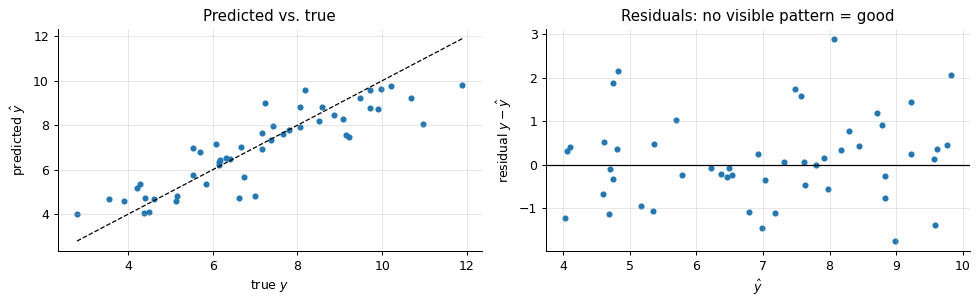

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

x_new = rng.uniform(0, 2, 50); y_new = 4 + 3 * x_new + rng.normal(0, 1, 50)
X_new = np.c_[np.ones(50), x_new]
y_hat = X_new @ theta_ne

mse = np.mean((y_new - y_hat) ** 2)
r2 = 1 - np.sum((y_new - y_hat) ** 2) / np.sum((y_new - y_new.mean()) ** 2)
print(f"MSE  = {mse:.3f}  (sklearn {mean_squared_error(y_new, y_hat):.3f})")
print(f"RMSE = {np.sqrt(mse):.3f}")
print(f"MAE  = {np.mean(np.abs(y_new - y_hat)):.3f}  (sklearn {mean_absolute_error(y_new, y_hat):.3f})")
print(f"R^2  = {r2:.3f}  (sklearn {r2_score(y_new, y_hat):.3f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].scatter(y_new, y_hat, s=15); lim = [y_new.min(), y_new.max()]
axes[0].plot(lim, lim, "k--", lw=1); axes[0].set_xlabel("true $y$"); axes[0].set_ylabel(r"predicted $\hat{y}$"); axes[0].set_title("Predicted vs. true")
axes[1].scatter(y_hat, y_new - y_hat, s=15); axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel(r"$\hat{y}$"); axes[1].set_ylabel(r"residual $y-\hat{y}$"); axes[1].set_title("Residuals: no visible pattern = good")
plt.tight_layout(); plt.show()

## Summary

- Model: $h_{\boldsymbol{\theta}}(\mathbf{x}) = \boldsymbol{\theta}^\top\mathbf{x}$; loss: $J(\boldsymbol{\theta}) = \frac{1}{2m}\lVert\mathbf{X}\boldsymbol{\theta}-\mathbf{y}\rVert^2$.
- Gradient: $\nabla J = \frac{1}{m}\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta}-\mathbf{y})$; batch GD: $\boldsymbol{\theta}\leftarrow\boldsymbol{\theta}-\alpha\nabla J$.
- GD converges iff $0<\alpha<2/\lambda_{\max}(\frac1m\mathbf{X}^\top\mathbf{X})$; standardise features to make it fast.
- Closed form: $\boldsymbol{\theta}^* = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$ (columns of $\mathbf{X}$ must be independent).
- $J$ is convex (Hessian $\frac1m\mathbf{X}^\top\mathbf{X}$ is PSD): any zero-gradient point is the global minimum.
- Least squares = MLE under i.i.d. Gaussian noise.
- Report RMSE/MAE (in the units of $y$) and $R^2$ on held-out data; check residuals.